# Day 05. 다중분류와 평가 지표

## 1) 오늘의 학습 목표

- 이진분류와 다중분류의 출력 차이를 이해한다.
- logits, softmax, cross entropy의 역할을 구분한다.
- NumPy와 PyTorch로 3개 클래스 선형분류 흐름을 비교한다.
- confusion matrix로 클래스별 성능을 확인한다.


## 2) 다중 분류 모델의 출력

* 다중분류 모델은 클래스 개수만큼 점수(logits)를 출력합니다. softmax는 이 점수들을 확률처럼 해석할 수 있게 바꾸고, cross entropy는 정답 클래스의 확률이 높아지도록 학습을 이끕니다.





### 2-1) Softmax
* 모델의 출력들을 0~1사이의 확률로 출력할 수 있도록 하며, 모든 클래스 출력의 합이 1입니다.
* 지수 함수를 활용함으로써 입력값 간의 차이를 극대화하도록 합니다. 가장 큰 값은 1에 가깝게 하고, 나머지 값들은 0에 수렴하도록 합니다.
* 지수 함수를 사용하기 때문에 미분 계산이 쉽도록 합니다.
$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

## 3) 예제: softmax와 cross entropy

logits가 확률로 바뀌는 과정을 직접 확인합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시스템에 설치된 폰트 중 'Nanum'이 포함된 폰트 이름 전체 출력
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

# 우분투에 설치한 나눔고딕으로 설정
plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

plt.rcParams["figure.figsize"] = (6, 4)

def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True) # 순전파 과정에서 발생하는 수치적 오버플로우(Numerical Overflow) 방지
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)

logits = np.array([
    [2.0, 1.0, 0.1],
    [0.2, 1.8, 0.5],
    [0.3, 0.4, 2.2],
])
y_true = np.array([0, 1, 2])

probs = softmax(logits)
ce = -np.mean(np.log(probs[np.arange(len(y_true)), y_true] + 1e-9))

print("softmax 확률:")
print(np.round(probs, 3))
print("cross entropy:", round(ce, 4))
print("예측 클래스:", probs.argmax(axis=1))


softmax 확률:
[[0.659 0.242 0.099]
 [0.137 0.678 0.185]
 [0.114 0.126 0.761]]
cross entropy: 0.3597
예측 클래스: [0 1 2]


## 4) 실습 1: 3개 클래스 데이터 만들기

작은 2차원 데이터를 직접 생성합니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

******************** 입력 raw 데이터 ********************
[[ 1.16144803  1.67980479]
 [ 0.19615094  1.75897608]
 [ 0.97870725  0.64000964]
 [ 0.63866948  0.51273257]
 [ 0.89935959  1.37524788]
 [ 1.26282868  1.28722871]
 [ 0.23733622  0.29306705]
 [ 1.69921143  1.43599841]
 [ 1.9824463   1.54441713]
 [ 0.5390239   1.5783726 ]
 [ 1.28277742  1.09667122]
 [ 0.631057    1.0012511 ]
 [ 0.93385058  1.4016408 ]
 [ 1.05602362  1.71313566]
 [ 0.65148141  1.21199615]
 [ 1.22447907  0.61104766]
 [ 0.46843028  1.45611078]
 [ 1.23284821  0.92687267]
 [ 1.17746533  0.69609519]
 [ 1.10725669  0.72769299]
 [ 1.08495481  1.44374026]
 [ 0.84716639  1.38239821]
 [ 0.5346103   0.87017915]
 [ 0.38586583  0.95473626]
 [ 1.03539434  0.9112318 ]
 [ 0.87954593  1.60308761]
 [ 1.64070678  0.45296605]
 [ 1.52835152  0.22461867]
 [ 0.66948434  0.92194948]
 [ 1.04997727  0.5286625 ]
 [ 0.67488905  1.03449422]
 [ 0.68795977  0.71145964]
 [ 1.29981855  1.41927447]
 [ 0.97297524  1.00818906]
 [ 0.99118085  0.79548027]
 [

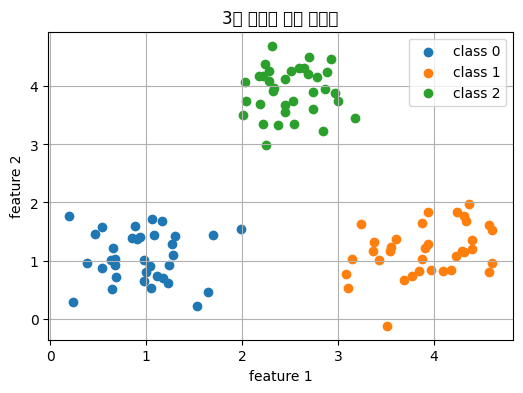

In [2]:
rng = np.random.default_rng(21)
centers = np.array([
    [1.0, 1.0],
    [4.0, 1.2],
    [2.5, 4.0],
])

X_raw = np.vstack([
    rng.normal(loc=center, scale=0.45, size=(35, 2))
    for center in centers
])
print("*"*20, "입력 raw 데이터", "*"*20)
print(X_raw)
print("X_raw shape: ", X_raw.shape)
y = np.repeat([0, 1, 2], 35)
print("*"*20, "정답 데이터", "*"*20)
print(y)

for class_id in range(3):
    plt.scatter(X_raw[y == class_id, 0], X_raw[y == class_id, 1], label=f"class {class_id}")

plt.title("3개 클래스 분류 데이터")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.grid(True)
plt.show()


## 5) 실습 2: softmax regression 학습하기

가중치 행렬 `W`는 각 클래스의 분류기를 나란히 둔 것처럼 볼 수 있습니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

최종 cross entropy: 0.0067
W shape: (2, 3)


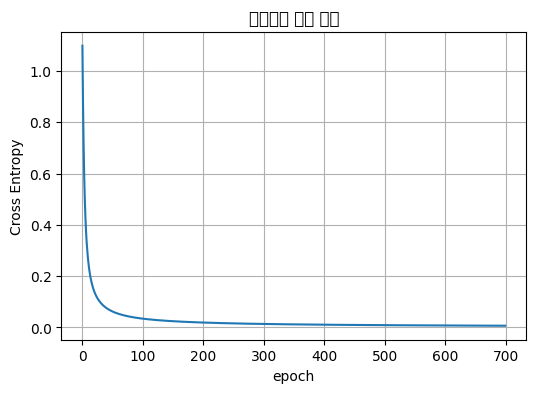

In [3]:
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

num_features = X.shape[1]
num_classes = 3
W = np.zeros((num_features, num_classes))
b = np.zeros(num_classes)
y_one_hot = np.eye(num_classes)[y]

lr = 0.4
losses = []

for epoch in range(700):
    logits = X @ W + b
    probs = softmax(logits)
    loss = -np.mean(np.log(probs[np.arange(len(y)), y] + 1e-9))
    losses.append(loss)

    grad_logits = (probs - y_one_hot) / len(y)
    grad_W = X.T @ grad_logits
    grad_b = grad_logits.sum(axis=0)
    W -= lr * grad_W
    b -= lr * grad_b

print("최종 cross entropy:", round(losses[-1], 4))
print("W shape:", W.shape)

plt.plot(losses)
plt.title("다중분류 학습 손실")
plt.xlabel("epoch")
plt.ylabel("Cross Entropy")
plt.grid(True)
plt.show()


## 6) 실습 3: confusion matrix 확인하기

어떤 클래스를 어떤 클래스로 헷갈렸는지 행렬로 확인합니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


Confusion Matrix (행=정답, 열=예측)
[[35  0  0]
 [ 0 35  0]
 [ 0  0 35]]
전체 정확도: 1.0
class 0 정확도: 1.0
class 1 정확도: 1.0
class 2 정확도: 1.0


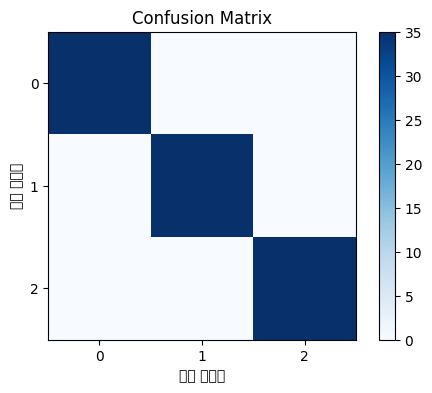

In [4]:
final_probs = softmax(X @ W + b)
pred = final_probs.argmax(axis=1)

cm = np.zeros((num_classes, num_classes), dtype=int)
for true_label, pred_label in zip(y, pred):
    cm[true_label, pred_label] += 1

print("Confusion Matrix (행=정답, 열=예측)")
print(cm)
print("전체 정확도:", round((pred == y).mean(), 3))

for class_id in range(num_classes):
    class_accuracy = cm[class_id, class_id] / cm[class_id].sum()
    print(f"class {class_id} 정확도:", round(class_accuracy, 3))

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("예측 클래스")
plt.ylabel("정답 클래스")
plt.colorbar()
plt.xticks(range(num_classes))
plt.yticks(range(num_classes))
plt.show()


## 7) 실습 TODO: PyTorch로 다중분류 선형모델 학습하기

다중분류에서는 모델이 클래스 수만큼 logit을 출력합니다. PyTorch의 `CrossEntropyLoss`는 raw logits와 정답 class index를 입력으로 받습니다.  
따라서 손실 계산 전에 직접 softmax를 적용하지 않습니다.


In [30]:
import torch

torch.manual_seed(21)
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X, dtype=torch.float32, device=torch_device)
y_tensor = torch.tensor(y, dtype=torch.long, device=torch_device)

multi_model = torch.nn.Sequential(torch.nn.Linear(2, num_classes)).to(torch_device)
ce_loss_fn = torch.nn.CrossEntropyLoss()
multi_optimizer = torch.optim.SGD(multi_model.parameters(), lr=0.25)

# 학습 loop 코드 작성
for epoch in range(150):
    multi_model.train()
    multi_optimizer.zero_grad()
    multi_model_logits = multi_model(X_tensor)
    multi_model_loss = ce_loss_fn(multi_model_logits, y_tensor)
    multi_model_loss.backward()
    multi_optimizer.step()

with torch.no_grad():
    # 모델의 logit 저장
    multi_model.eval()
    torch_logits = multi_model(X_tensor)

    # 데이터별 모델이 예측한 클래스 결과 저장
    torch_pred = torch_logits.argmax(dim=1).cpu().numpy()

    # softmax를 통과하여 0~1사이의 확률로 출력해서 저장
    torch_prob = torch.softmax(torch_logits, dim=1).cpu().numpy()

print("마지막 PyTorch CE:", round(float(torch_loss.detach().cpu()), 4))
# 미분 계산 과정에서 데이터를 떼어낸다.
print("PyTorch 정확도:", round(float((torch_pred == y).mean()), 3))
print("첫 번째 샘플 확률:", np.round(torch_prob[0], 3))

마지막 PyTorch CE: 0.0365
PyTorch 정확도: 1.0
첫 번째 샘플 확률: [0.936 0.016 0.048]


## 8) 실습 TODO: PyTorch 새 점 예측하기

새 좌표를 바꿔 PyTorch 모델이 어느 클래스로 보는지 확인하세요.


In [31]:
# TODO: 좌표를 바꿔 클래스별 확률과 예측 클래스를 비교해 보세요.
torch_new_point = np.array([[2.4, 3.6]])

# 새 데이터를 표준화 한 후 float32 타입에 torch_device에서 작동되도록 하는 새로운 텐서 생성
torch_new_scaled = (torch_new_point - X_mean) / X_std
# torch_new_tensor = torch.tensor(torch_new_scaled, dtype=torch.float32).to(torch_device)
torch_new_tensor = torch.tensor(torch_new_scaled, dtype=torch.float32, device=torch_device)

with torch.no_grad():
    torch_new_logits = multi_model(torch_new_tensor)
    torch_new_prob = torch.softmax(torch_new_logits, dim=1).cpu().numpy()

print("PyTorch 클래스별 확률:", np.round(torch_new_prob[0], 3))
print("PyTorch 예측 클래스:", int(torch_new_prob.argmax(axis=1)[0]))


PyTorch 클래스별 확률: [0.023 0.016 0.96 ]
PyTorch 예측 클래스: 2


## 7) 미니 퀴즈

1. 다중분류 모델의 출력 차원은 무엇으로 결정되나요?
- 분류 클래스의 개수
2. softmax를 적용하면 각 행의 확률 합은 얼마가 되나요?
- 확률 합은 1이다.
3. PyTorch `CrossEntropyLoss`에는 softmax 적용 전 logits와 적용 후 확률 중 무엇을 넣나요?
- softmax 적용 전 logits(예측값)을 넣는다.
- CrossEntropyLoss 내부에서 log_softmax와 NLLLoss 계이 이루어진다.
4. `argmax`는 다중분류에서 어떤 역할을 하나요?
- 가장 높은 예측값(logit 또는 prob)을 가진 클래스의 인덱스를 선택해 최종 예측 클래스를 결정한다.
5. confusion matrix에서 행과 열은 각각 무엇을 의미하나요?
- 행: 실제값, 열: 예측값을 의미한다.
- 행은 실제 클래스(actual label), 열은 예측 클래스(predicted label)를 의미한다.


## 8) 오늘의 정리

- 다중분류는 클래스 수만큼 점수를 출력합니다.
- softmax는 logits를 클래스별 확률로 바꿉니다.
- PyTorch의 `CrossEntropyLoss`는 logits와 class index를 받아 학습합니다.
- confusion matrix는 어떤 클래스에서 오분류가 생기는지 확인하게 해줍니다.
